In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data, timeseries_train_test_split


/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-23 15:39:11,590	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-01-23 15:39:11.763571: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-23 15:39:11.763593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-23 15:39:11.764504: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to re

In [2]:
!pwd

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/branching_simulation


In [15]:
b_function = 'AND_distractors'

# Load x and b
x = np.load(f"data/x_{b_function}.npy")
b = np.load(f"data/b_{b_function}.npy")
print(x.shape, b.shape)

(200, 100, 4) (200, 100)


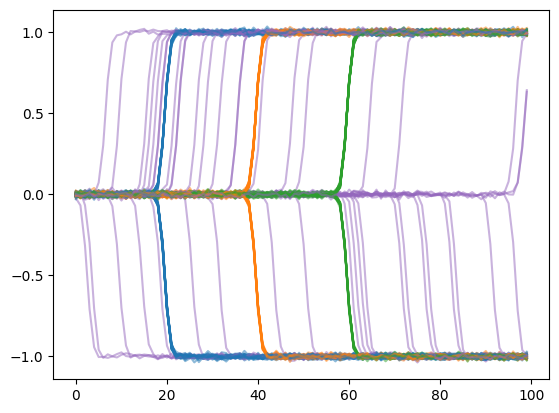

In [16]:
for i in range(45):
    color_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
    for j in range(4):
        plt.plot(x[i,:, j], c=color_list[j], alpha=0.5)


In [89]:
x_ = x.reshape(-1,4)
b_ = (b[:,-1][:,np.newaxis] *  np.ones_like(b)).reshape(-1)
print(x_.shape, b_.shape)

# Train test split
split_frac = 0.1
split_ind = int(b_.shape[0]*split_frac)
x_train, x_test, b_train, b_test = x_[:-split_ind], x_[-split_ind:], b_[:-split_ind], b_[-split_ind:]
x_train.shape, x_test.shape, b_train.shape, b_test.shape 

(20000, 4) (20000,)


((18000, 4), (2000, 4), (18000,), (2000,))

In [90]:
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.neural_network import MLPClassifier
#clf = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5), random_state=1)
clf = RFC(n_estimators = 1000, max_features = 3, min_samples_split= 1000)
#clf = LR()
clf.fit(x_train, b_train)
print('train score: ', clf.score(x_train, b_train))
print('test score: ', clf.score(x_test, b_test))
b_proba = clf.predict_proba(x_train)

train score:  0.9370555555555555
test score:  0.9415


In [91]:
x_train.shape, b_train.shape

((18000, 4), (18000,))

In [92]:
x_train = x_train.reshape(-1,100,x_train.shape[-1])
b_train = b_train.reshape(-1,100)
b_proba = b_proba.reshape(-1,100,b_proba.shape[-1])
print(x_train.shape)

(180, 100, 4)


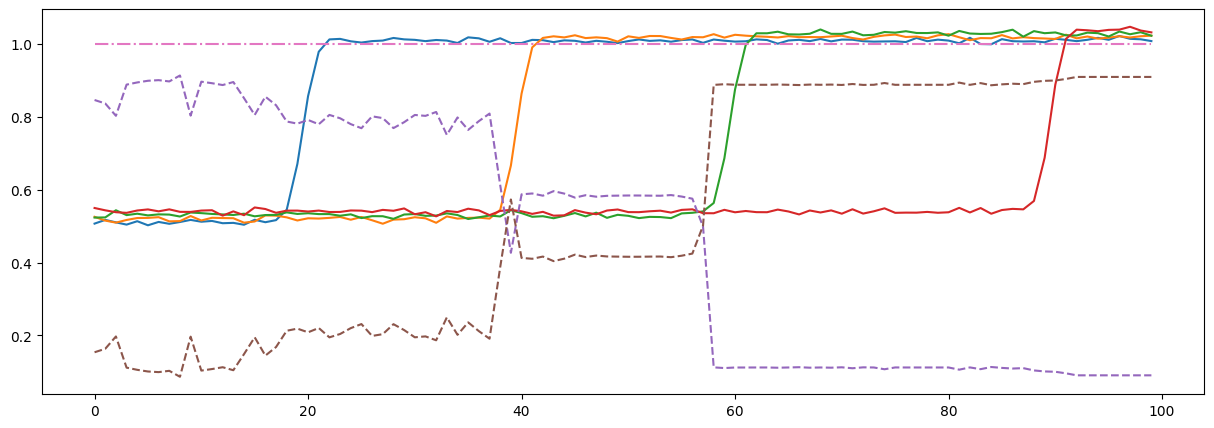

In [93]:
trial_no = 96
plt.figure(figsize=(15,5))
plt.plot(x_train[trial_no]/2 + 0.5 + .01*np.array([1,2,3,4]))
plt.plot(b_proba[trial_no], '--')
plt.plot(b_train[trial_no] , '-.')
plt.show()

(0.0, 1.0, 0.0, 1.0)

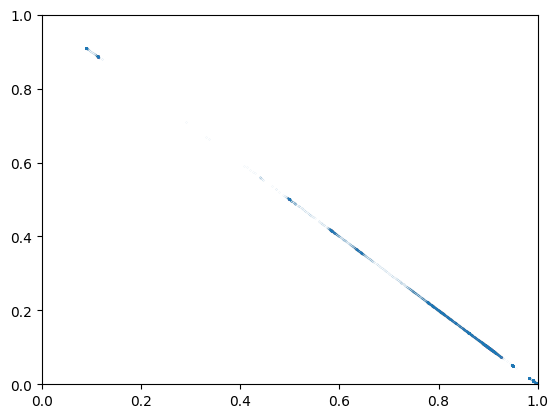

In [94]:
probs = b_proba.reshape(-1,2)
plt.scatter(probs[:,0], probs[:,1], s=0.001)
plt.axis([0,1,0,1])